In [1]:
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import gc
import pickle
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from joblib import Parallel, delayed
from peft import PeftModel
from PIL import Image
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits
from tqdm.auto import tqdm
from transformers import AutoModel, AutoModelForImageTextToText, AutoProcessor

import os
os.environ['CUDA_VISIBLE_DEVICES'] = "3"


/home/tdnguyen/miniforge3/envs/cxr-vlm-interp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Constants.

DATA_CSV = Path("artifacts/processed_data/chexpertplus_frontal_5labels.csv")
RESULTS_DIR = Path("artifacts/results")
PROBES_DIR = Path("artifacts/probes")
PLOTS_DIR = Path("artifacts/plots")

METRICS_CSV = RESULTS_DIR / "experiment_metrics.csv"
YES_NO_CSV = RESULTS_DIR / "experiment_yes_no_scores.csv"

MEDSIGLIP_MODEL_ID = "google/medsiglip-448"
MEDGEMMA_MODEL_ID = "google/medgemma-4b-it"
MODEL_DTYPE = torch.bfloat16
FEATURE_DTYPE = np.float32

models = [
    {"name": "base_medgemma", "adapter_path": None},
    {"name": "lora_image_first", "adapter_path": Path("artifacts/lora_sft/image_first_adapter")},
    {"name": "lora_text_first", "adapter_path": Path("artifacts/lora_sft/text_first_adapter")},
]

IMAGE_LOAD_NUM_WORKERS = 4
MEDSIGLIP_BATCH_SIZE = 512
MEDGEMMA_BATCH_SIZE = 24
PROBE_PARALLEL_JOBS = 16
PROBE_INNER_NUM_THREADS = 8
MAX_ITER = 2000
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

TARGET_LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion",
]

for folder in [RESULTS_DIR, PROBES_DIR, PLOTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


In [3]:
# Load the processed CheXpert+ manifest.

df = pd.read_csv(DATA_CSV)
labels = (df[TARGET_LABELS].to_numpy() == 1).astype(np.int8)
train_idx = np.where(df["probe_split"].to_numpy() == "train")[0]
test_idx = np.where(df["probe_split"].to_numpy() == "test")[0]
image_paths = df["image_path"].tolist()

print("rows", len(df))
print("train", len(train_idx), "test", len(test_idx))
display(pd.DataFrame({
    "label": TARGET_LABELS,
    "train_positive_rate": labels[train_idx].mean(axis=0),
    "test_positive_rate": labels[test_idx].mean(axis=0),
}))


rows 25000
train 20000 test 5000


,label,train_positive_rate,test_positive_rate
0,Atelectasis,0.30930,0.3044
1,Cardiomegaly,0.22200,0.2196
2,Consolidation,0.17995,0.1752
3,Edema,0.29075,0.2754
4,Pleural Effusion,0.47520,0.4572


In [4]:
# Minimal helpers.

def slug(text):
    return re.sub(r"[^a-z0-9]+", "_", str(text).lower()).strip("_")


def load_rgb(path):
    with Image.open(path) as image:
        return image.convert("RGB").copy()


def fit_probe(feature_matrix, layer, label, model_name, prompt_order, condition, feature_name):
    label_i = TARGET_LABELS.index(label)
    x = feature_matrix if layer is None else feature_matrix[:, layer, :]
    x_train = x[train_idx].astype(np.float32, copy=False)
    x_test = x[test_idx].astype(np.float32, copy=False)
    y_train = labels[train_idx, label_i]
    y_test = labels[test_idx, label_i]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=1.0, solver="lbfgs", max_iter=MAX_ITER, random_state=RANDOM_STATE),
    )

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        with threadpool_limits(limits=PROBE_INNER_NUM_THREADS):
            model.fit(x_train, y_train)

    layer_name = "layer_none" if layer is None else f"layer_{int(layer):02d}"
    model_path = PROBES_DIR / slug(model_name) / slug(prompt_order) / slug(label) / layer_name / f"{slug(feature_name)}.pkl"
    model_path.parent.mkdir(parents=True, exist_ok=True)
    with model_path.open("wb") as f:
        pickle.dump(model, f)

    scores = model.predict_proba(x_test)[:, 1]
    return {
        "model_name": model_name,
        "prompt_order": prompt_order,
        "condition": condition,
        "feature": feature_name,
        "layer": layer,
        "label": label,
        "feature_dim": int(x_train.shape[1]),
        "positive_prevalence": float(y_test.mean()),
        "auroc": float(roc_auc_score(y_test, scores)),
        "auprc": float(average_precision_score(y_test, scores)),
        "n_iter": int(model.named_steps["logisticregression"].n_iter_[0]),
        "model_path": str(model_path),
    }


In [5]:
# Cache images in CPU RAM once.

with ThreadPoolExecutor(max_workers=IMAGE_LOAD_NUM_WORKERS) as pool:
    images = list(tqdm(pool.map(load_rgb, image_paths), total=len(image_paths), desc="Load images"))

print("cached images", len(images))


Load images: 100%|██████████| 25000/25000 [08:32<00:00, 48.79it/s]

cached images 25000


In [6]:
# Prepare output containers.

metric_rows = []
yes_no_rows = []


In [7]:
# Extract standalone MedSigLIP features and train baseline probes.

device = "cuda" if torch.cuda.is_available() else "cpu"
medsiglip_processor = AutoProcessor.from_pretrained(MEDSIGLIP_MODEL_ID)
medsiglip_model = AutoModel.from_pretrained(MEDSIGLIP_MODEL_ID, dtype=MODEL_DTYPE).to(device).eval()
medsiglip_dim = medsiglip_model.config.vision_config.hidden_size
medsiglip_features = np.empty((len(df), medsiglip_dim), dtype=FEATURE_DTYPE)

for start in tqdm(range(0, len(images), MEDSIGLIP_BATCH_SIZE), desc="MedSigLIP"):
    end = min(start + MEDSIGLIP_BATCH_SIZE, len(images))
    inputs = medsiglip_processor(images=images[start:end], return_tensors="pt")
    inputs = {
        k: v.to(device=device, dtype=MODEL_DTYPE) if v.is_floating_point() else v.to(device=device)
        for k, v in inputs.items()
    }
    with torch.inference_mode():
        outputs = medsiglip_model.get_image_features(**inputs)
        emb = outputs.pooler_output if hasattr(outputs, "pooler_output") else outputs
        emb = emb / emb.norm(p=2, dim=-1, keepdim=True)
    medsiglip_features[start:end] = emb.float().cpu().numpy().astype(FEATURE_DTYPE)

jobs = [(None, label) for label in TARGET_LABELS]
metric_rows.extend(Parallel(n_jobs=PROBE_PARALLEL_JOBS, prefer="threads")(
    delayed(fit_probe)(medsiglip_features, layer, label, "medsiglip_standalone", "baseline", "medsiglip_standalone", "medsiglip_standalone")
    for layer, label in tqdm(jobs, desc="MedSigLIP probes")
))

del medsiglip_model, medsiglip_processor, medsiglip_features
gc.collect()
torch.cuda.empty_cache()


MedSigLIP probes: 100%|██████████| 5/5 [00:00<00:00, 6349.23it/s]


In [8]:
# Load MedGemma processor and process images once with the MedGemma image processor.

medgemma_processor = AutoProcessor.from_pretrained(MEDGEMMA_MODEL_ID)

pixel_chunks = []
for start in tqdm(range(0, len(images), MEDGEMMA_BATCH_SIZE), desc="MedGemma image processor"):
    end = min(start + MEDGEMMA_BATCH_SIZE, len(images))
    pixel_inputs = medgemma_processor.image_processor(images=images[start:end], return_tensors="pt", do_pan_and_scan=False)
    pixel_chunks.append(pixel_inputs["pixel_values"].to(dtype=MODEL_DTYPE, device="cpu"))
medgemma_pixel_values = torch.cat(pixel_chunks, dim=0)
del pixel_chunks

print("cached pixel_values", tuple(medgemma_pixel_values.shape), medgemma_pixel_values.dtype)


MedGemma image processor: 100%|██████████| 1042/1042 [21:18<00:00,  1.23s/it]


cached pixel_values (25000, 3, 896, 896) torch.bfloat16


In [9]:
# Prompt/token helpers kept here because the image token expansion must match Gemma 3 processing.

def prompt_text(prompt_order, label):
    question = f"Question: Is there {label.lower()} in this image? Answer yes or no."
    image_item = {"type": "image"}
    if prompt_order == "image_first":
        content = [image_item, {"type": "text", "text": f"\n{question}\nAnswer: "}]
    else:
        content = [{"type": "text", "text": f"{question}\n"}, image_item, {"type": "text", "text": "\nAnswer: "}]
    messages = [{"role": "user", "content": content}]
    text = medgemma_processor.apply_chat_template(messages, add_generation_prompt=False, tokenize=False)
    if isinstance(text, list):
        text = text[0]
    return text.replace(medgemma_processor.boi_token, medgemma_processor.full_image_sequence)


def tokenize_prompt(prompt_order, label, batch_size):
    inputs = medgemma_processor.tokenizer(
        [prompt_text(prompt_order, label)] * batch_size,
        return_tensors="pt",
        padding=True,
    )

    if hasattr(medgemma_processor, "create_mm_token_type_ids"):
        token_type_ids = medgemma_processor.create_mm_token_type_ids(inputs["input_ids"])
        if not torch.is_tensor(token_type_ids):
            token_type_ids = torch.tensor(token_type_ids)
        inputs["token_type_ids"] = token_type_ids

    return inputs

YES_TOKEN_ID = medgemma_processor.tokenizer("yes", add_special_tokens=False).input_ids[0]
NO_TOKEN_ID = medgemma_processor.tokenizer("no", add_special_tokens=False).input_ids[0]
print("yes/no token ids", YES_TOKEN_ID, NO_TOKEN_ID)


yes/no token ids 4443 1904


In [10]:
# Run each MedGemma model, train probes, and collect yes/no scores.

for model_info in models:
    model_name = model_info["name"]
    adapter_path = model_info["adapter_path"]
    print("model", model_name)

    medgemma_model = AutoModelForImageTextToText.from_pretrained(
        MEDGEMMA_MODEL_ID,
        dtype=MODEL_DTYPE,
        device_map="auto",
    ).eval()
    if adapter_path is not None:
        medgemma_model = PeftModel.from_pretrained(medgemma_model, str(adapter_path)).eval()

    model_device = next(medgemma_model.parameters()).device
    model_config = medgemma_model.config if hasattr(medgemma_model, "config") else medgemma_model.base_model.model.config
    num_layers = model_config.text_config.num_hidden_layers
    hidden_size = model_config.text_config.hidden_size
    vision_hidden_size = model_config.vision_config.hidden_size
    image_token_id = getattr(model_config, "image_token_id", None)
    if image_token_id is None:
        image_token_id = getattr(model_config, "image_token_index")

    pre_projector_cache = {}
    projector_norm = next(module for name, module in medgemma_model.named_modules() if name.endswith("multi_modal_projector.mm_soft_emb_norm"))
    projector_hook = projector_norm.register_forward_hook(lambda module, inputs, output: pre_projector_cache.__setitem__("x", inputs[0].detach()))

    check_inputs = tokenize_prompt("image_first", TARGET_LABELS[0], 1)
    print("num_layers", num_layers, "hidden_size", hidden_size, "vision_hidden_size", vision_hidden_size)
    print("image token count", int(check_inputs["input_ids"].eq(image_token_id).sum().item()))

    for prompt_order in ["image_first", "text_first"]:
        for label in TARGET_LABELS:
            print(model_name, prompt_order, label)

            preprojector_features = np.empty((len(df), vision_hidden_size), dtype=FEATURE_DTYPE)
            predecoder_features = np.empty((len(df), hidden_size), dtype=FEATURE_DTYPE)
            layer_mean_features = np.empty((len(df), num_layers, hidden_size), dtype=FEATURE_DTYPE)
            layer_last_features = np.empty((len(df), num_layers, hidden_size), dtype=FEATURE_DTYPE)
            final_prompt_features = np.empty((len(df), num_layers, hidden_size), dtype=FEATURE_DTYPE)
            yes_logprob = np.empty(len(df), dtype=np.float32)
            no_logprob = np.empty(len(df), dtype=np.float32)

            for start in tqdm(range(0, len(df), MEDGEMMA_BATCH_SIZE), desc=f"{model_name} {prompt_order} {label}"):
                end = min(start + MEDGEMMA_BATCH_SIZE, len(df))
                batch_size = end - start
                inputs = tokenize_prompt(prompt_order, label, batch_size)
                inputs["pixel_values"] = medgemma_pixel_values[start:end]
                inputs = {
                    k: v.to(device=model_device, dtype=MODEL_DTYPE) if v.is_floating_point() else v.to(device=model_device)
                    for k, v in inputs.items()
                }

                with torch.inference_mode():
                    outputs = medgemma_model(
                        **inputs,
                        output_hidden_states=True,
                        use_cache=False,
                        logits_to_keep=1,
                        return_dict=True,
                    )

                preprojector_features[start:end] = pre_projector_cache["x"].float().mean(dim=1).cpu().numpy().astype(FEATURE_DTYPE)
                predecoder_features[start:end] = outputs.image_hidden_states.float().mean(dim=1).cpu().numpy().astype(FEATURE_DTYPE)

                log_probs = torch.log_softmax(outputs.logits[:, -1, :].float(), dim=-1)
                yes_logprob[start:end] = log_probs[:, YES_TOKEN_ID].cpu().numpy()
                no_logprob[start:end] = log_probs[:, NO_TOKEN_ID].cpu().numpy()

                image_mask = inputs["input_ids"].eq(image_token_id)
                image_token_count = int(image_mask.sum(dim=1)[0].item())
                last_positions = inputs["attention_mask"].sum(dim=1) - 1
                batch_arange = torch.arange(batch_size, device=model_device)

                for layer_i, hidden in enumerate(outputs.hidden_states[1:]):
                    image_hidden = hidden[image_mask].reshape(batch_size, image_token_count, hidden_size).float()
                    layer_mean_features[start:end, layer_i] = image_hidden.mean(dim=1).cpu().numpy().astype(FEATURE_DTYPE)
                    layer_last_features[start:end, layer_i] = image_hidden[:, -1].cpu().numpy().astype(FEATURE_DTYPE)
                    final_prompt_features[start:end, layer_i] = hidden[batch_arange, last_positions].float().cpu().numpy().astype(FEATURE_DTYPE)

                del outputs, inputs

            metric_rows.append(
                fit_probe(preprojector_features, None, label, model_name, prompt_order, label, "medgemma_pre_projector_mean_image_token")
            )
            metric_rows.append(
                fit_probe(predecoder_features, None, label, model_name, prompt_order, label, "medgemma_pre_decoder_mean_image_token")
            )

            for feature_name, feature_matrix in [
                ("medgemma_layer_mean_image_token", layer_mean_features),
                ("medgemma_layer_last_image_token", layer_last_features),
            ]:
                jobs = [(layer, label) for layer in range(num_layers)]
                metric_rows.extend(Parallel(n_jobs=PROBE_PARALLEL_JOBS, prefer="threads")(
                    delayed(fit_probe)(feature_matrix, layer, target_label, model_name, prompt_order, label, feature_name)
                    for layer, target_label in tqdm(jobs, desc=f"{feature_name} probes")
                ))

            jobs = [(layer, label) for layer in range(num_layers)]
            metric_rows.extend(Parallel(n_jobs=PROBE_PARALLEL_JOBS, prefer="threads")(
                delayed(fit_probe)(final_prompt_features, layer, target_label, model_name, prompt_order, label, "medgemma_layer_final_prompt_token")
                for layer, target_label in tqdm(jobs, desc="final prompt token probes")
            ))

            label_i = TARGET_LABELS.index(label)
            score = yes_logprob - no_logprob
            yes_no_rows.append(pd.DataFrame({
                "model_name": model_name,
                "study_id": df["study_id"],
                "subject_id": df["subject_id"],
                "dicom_id": df["dicom_id"],
                "probe_split": df["probe_split"],
                "prompt_order": prompt_order,
                "label": label,
                "y_true": labels[:, label_i],
                "logprob_yes": yes_logprob,
                "logprob_no": no_logprob,
                "score_yes_minus_no": score,
                "pred_yes": score > 0,
            }))
            metric_rows.append({
                "model_name": model_name,
                "prompt_order": prompt_order,
                "condition": label,
                "feature": "medgemma_yes_no_logprob",
                "layer": None,
                "label": label,
                "feature_dim": 1,
                "positive_prevalence": float(labels[test_idx, label_i].mean()),
                "auroc": float(roc_auc_score(labels[test_idx, label_i], score[test_idx])),
                "auprc": float(average_precision_score(labels[test_idx, label_i], score[test_idx])),
                "n_iter": None,
                "model_path": "",
            })

            del preprojector_features, predecoder_features, layer_mean_features, layer_last_features, final_prompt_features, yes_logprob, no_logprob
            gc.collect()
            torch.cuda.empty_cache()

    projector_hook.remove()
    del medgemma_model
    gc.collect()
    torch.cuda.empty_cache()


model base_medgemma


Loading weights: 100%|██████████| 883/883 [00:09<00:00, 98.00it/s] 


num_layers 34 hidden_size 2560 vision_hidden_size 1152
image token count 256
base_medgemma image_first Atelectasis


final prompt token probes: 100%|██████████| 34/34 [00:46<00:00,  1.38s/it]


base_medgemma image_first Cardiomegaly


...

final prompt token probes: 100%|██████████| 34/34 [00:59<00:00,  1.76s/it]


lora_text_first text_first Edema


final prompt token probes: 100%|██████████| 34/34 [00:47<00:00,  1.40s/it]


lora_text_first text_first Pleural Effusion


final prompt token probes: 100%|██████████| 34/34 [00:54<00:00,  1.61s/it]


In [11]:
# Save results.

metrics_df = pd.DataFrame(metric_rows)
metrics_df["layer"] = pd.to_numeric(metrics_df["layer"], errors="coerce")
metrics_df = metrics_df.sort_values(["model_name", "prompt_order", "condition", "feature", "layer", "label"], na_position="first")
yes_no_df = pd.concat(yes_no_rows, ignore_index=True)

metrics_df.to_csv(METRICS_CSV, index=False)
yes_no_df.to_csv(YES_NO_CSV, index=False)

print("metrics rows", len(metrics_df))
print("yes/no rows", len(yes_no_df))
print("saved", METRICS_CSV)
print("saved", YES_NO_CSV)
print("saved probes to", PROBES_DIR)

display(metrics_df)
display(
    metrics_df
    .groupby(["model_name", "prompt_order", "feature", "layer"], dropna=False, as_index=False)
    .agg(mean_auroc=("auroc", "mean"), mean_auprc=("auprc", "mean"))
    .sort_values("mean_auroc", ascending=False)
)


metrics rows 3155
yes/no rows 750000
saved artifacts/results/experiment_metrics.csv
saved artifacts/results/experiment_yes_no_scores.csv
saved probes to artifacts/probes


,model_name,prompt_order,condition,feature,layer,label,feature_dim,positive_prevalence,auroc,auprc,n_iter,model_path
75,base_medgemma,image_first,Atelectasis,medgemma_layer_final_prompt_token,0.0,Atelectasis,2560,0.3044,0.611944,0.396231,1046.0,artifacts/probes/base_medgemma/image_first/ate...
76,base_medgemma,image_first,Atelectasis,medgemma_layer_final_prompt_token,1.0,Atelectasis,2560,0.3044,0.618796,0.397446,891.0,artifacts/probes/base_medgemma/image_first/ate...
77,base_medgemma,image_first,Atelectasis,medgemma_layer_final_prompt_token,2.0,Atelectasis,2560,0.3044,0.618231,0.395363,733.0,artifacts/probes/base_medgemma/image_first/ate...
78,base_medgemma,image_first,Atelectasis,medgemma_layer_final_prompt_token,3.0,Atelectasis,2560,0.3044,0.611940,0.395087,611.0,artifacts/probes/base_medgemma/image_first/ate...
79,base_medgemma,image_first,Atelectasis,medgemma_layer_final_prompt_token,4.0,Atelectasis,2560,0.3044,0.614802,0.390804,809.0,artifacts/probes/base_medgemma/image_first/ate...
...,...,...,...,...,...,...,...,...,...,...,...,...
0,medsiglip_standalone,baseline,medsiglip_standalone,medsiglip_standalone,NaN,Atelectasis,1152,0.3044,0.668901,0.441514,843.0,artifacts/probes/medsiglip_standalone/baseline...
1,medsiglip_standalone,baseline,medsiglip_standalone,medsiglip_standalone,NaN,Cardiomegaly,1152,0.2196,0.811250,0.561554,728.0,artifacts/probes/medsiglip_standalone/baseline...
2,medsiglip_standalone,baseline,medsiglip_standalone,medsiglip_standalone,NaN,Consolidation,1152,0.1752,0.669648,0.282052,749.0,artifacts/probes/medsiglip_standalone/baseline...
3,medsiglip_standalone,baseline,medsiglip_standalone,medsiglip_standalone,NaN,Edema,1152,0.2754,0.795863,0.568540,732.0,artifacts/probes/medsiglip_standalone/baseline...


,model_name,prompt_order,feature,layer,mean_auroc,mean_auprc
314,lora_image_first,image_first,medgemma_yes_no_logprob,NaN,0.771805,0.543792
629,lora_text_first,text_first,medgemma_yes_no_logprob,NaN,0.769809,0.540889
524,lora_text_first,image_first,medgemma_yes_no_logprob,NaN,0.762613,0.530512
630,medsiglip_standalone,baseline,medsiglip_standalone,NaN,0.758976,0.535622
312,lora_image_first,image_first,medgemma_pre_decoder_mean_image_token,NaN,0.754659,0.531241
...,...,...,...,...,...,...
60,base_medgemma,image_first,medgemma_layer_last_image_token,26.0,0.662113,0.416408
58,base_medgemma,image_first,medgemma_layer_last_image_token,24.0,0.662086,0.417507
59,base_medgemma,image_first,medgemma_layer_last_image_token,25.0,0.661429,0.416852
67,base_medgemma,image_first,medgemma_layer_last_image_token,33.0,0.661380,0.414913


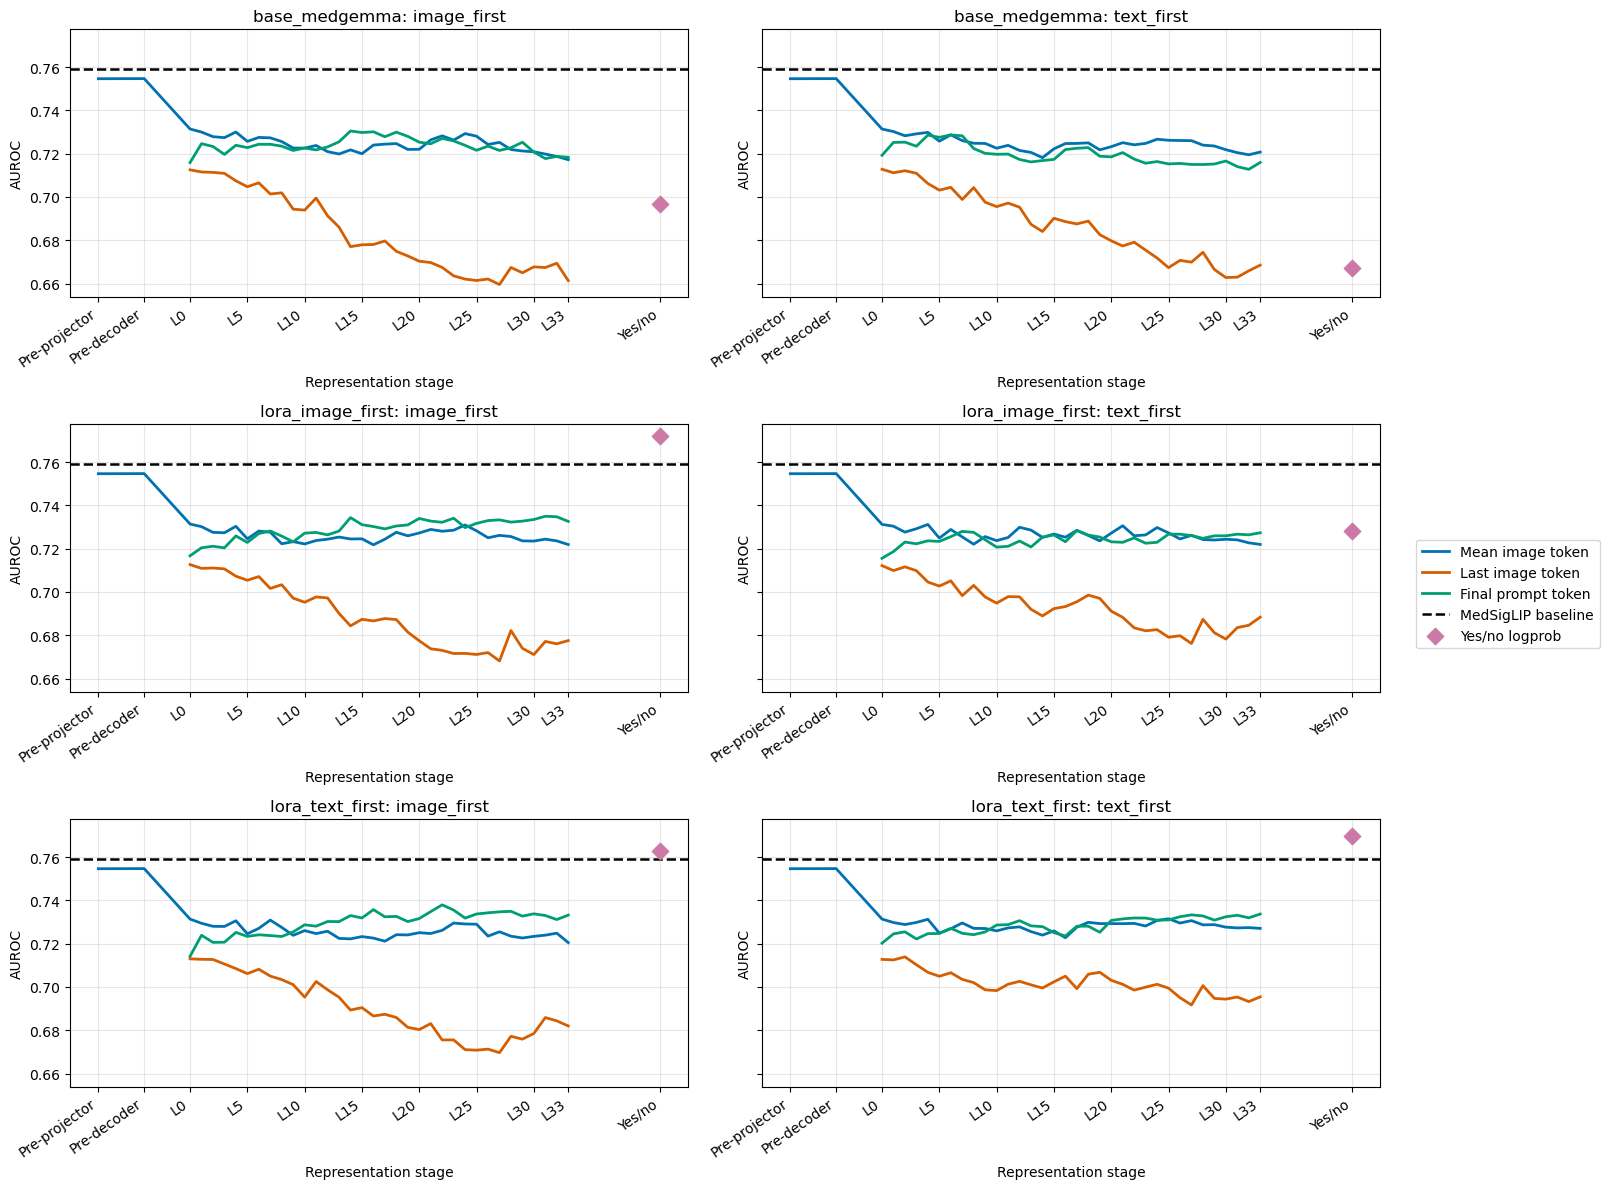

saved artifacts/plots/mean_auroc_over_layers.png


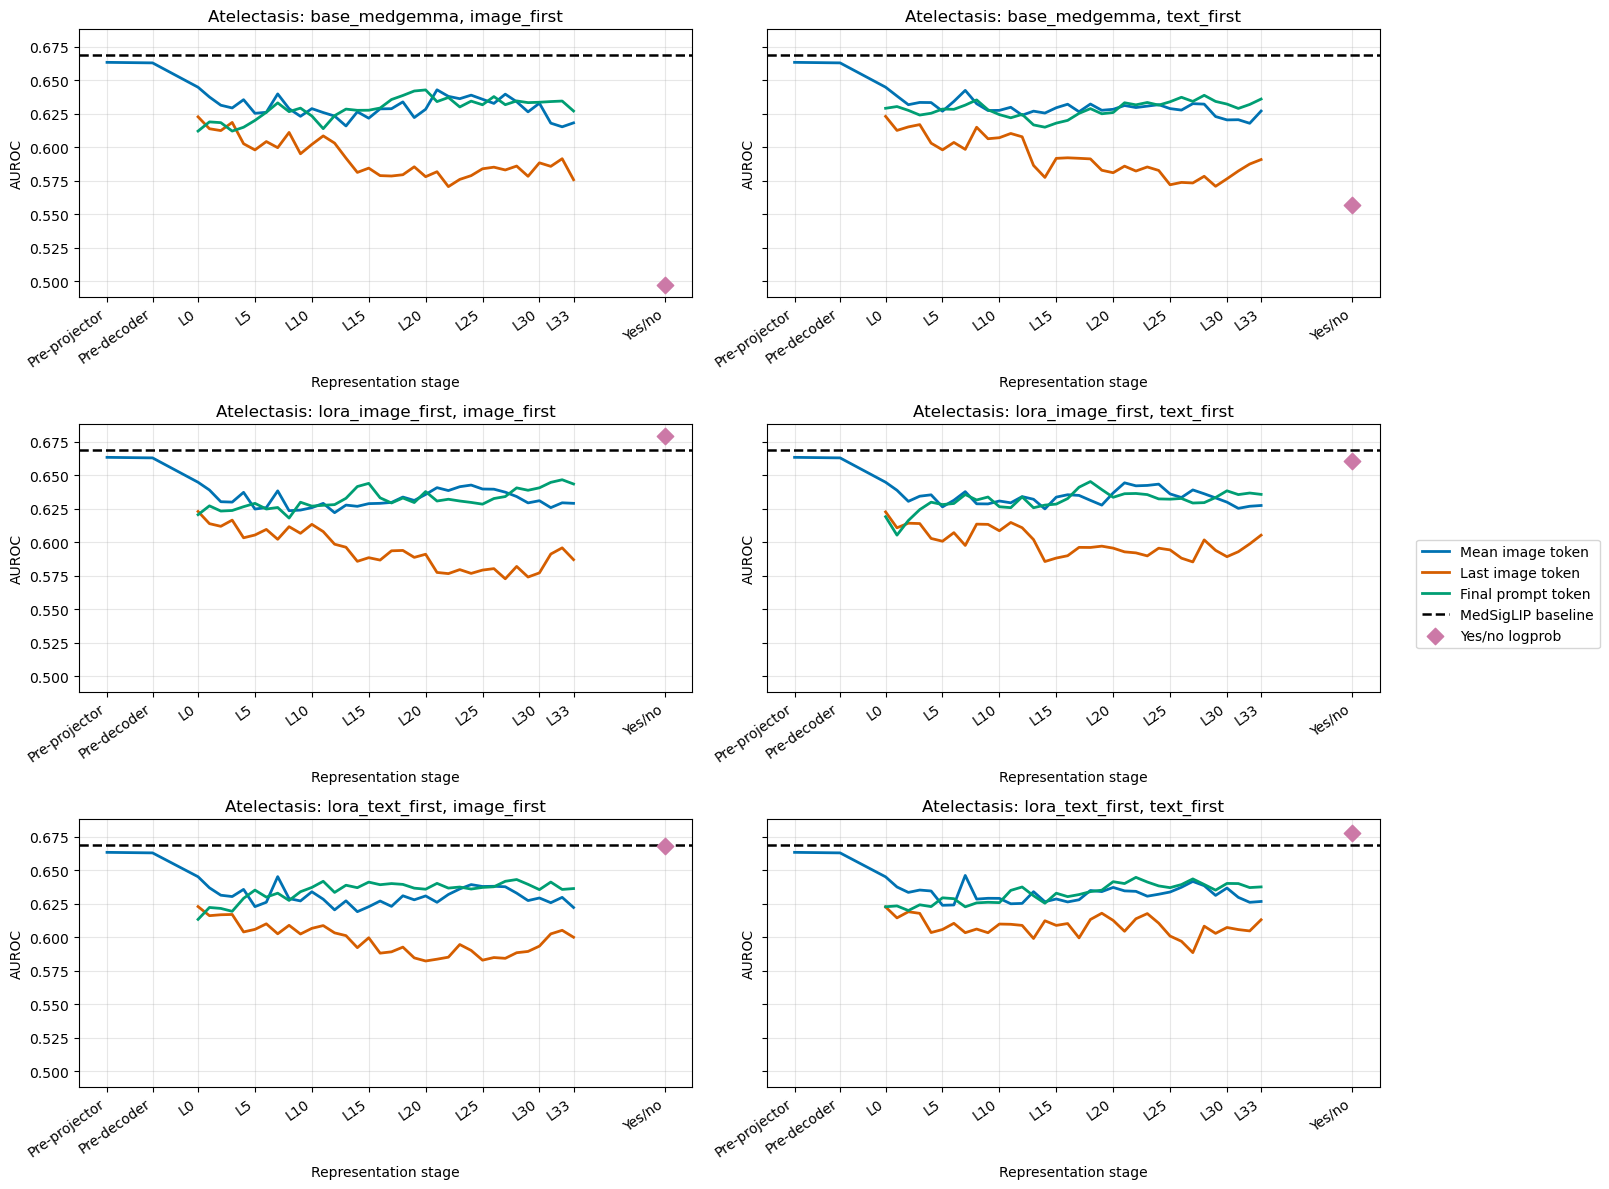

saved artifacts/plots/atelectasis_auroc_over_layers.png


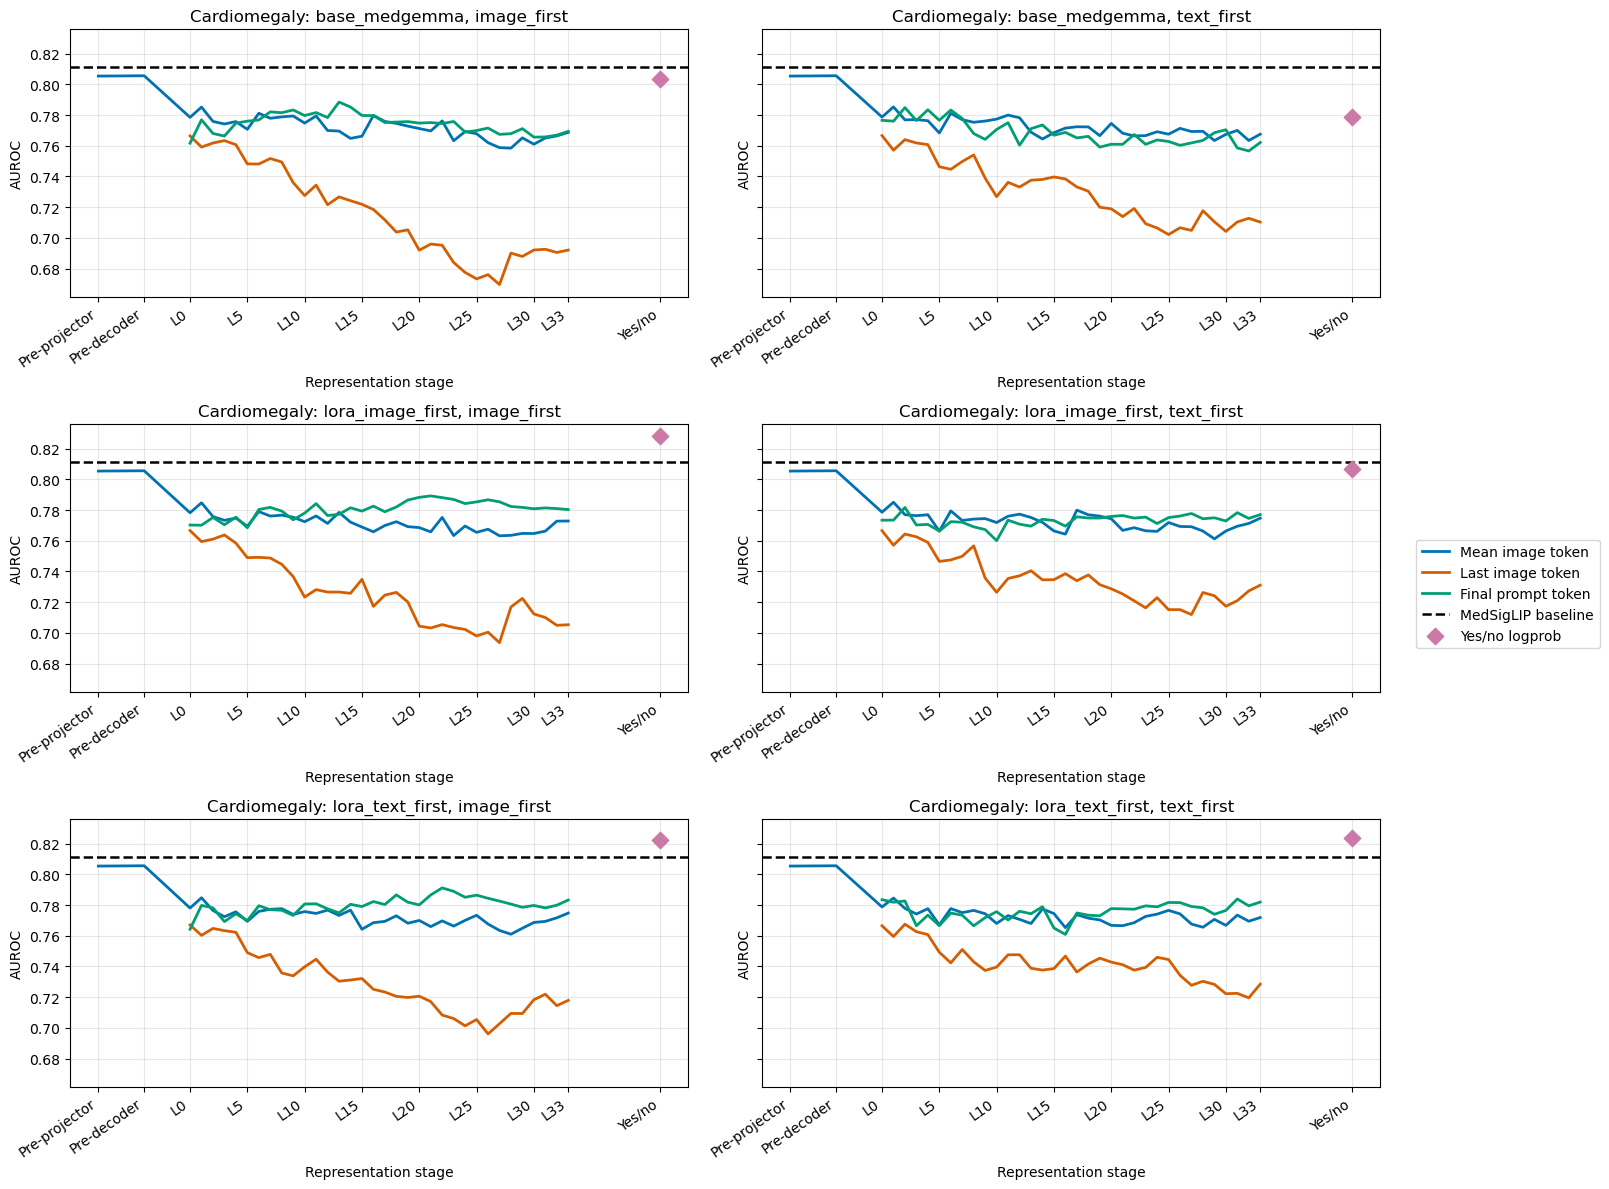

saved artifacts/plots/cardiomegaly_auroc_over_layers.png


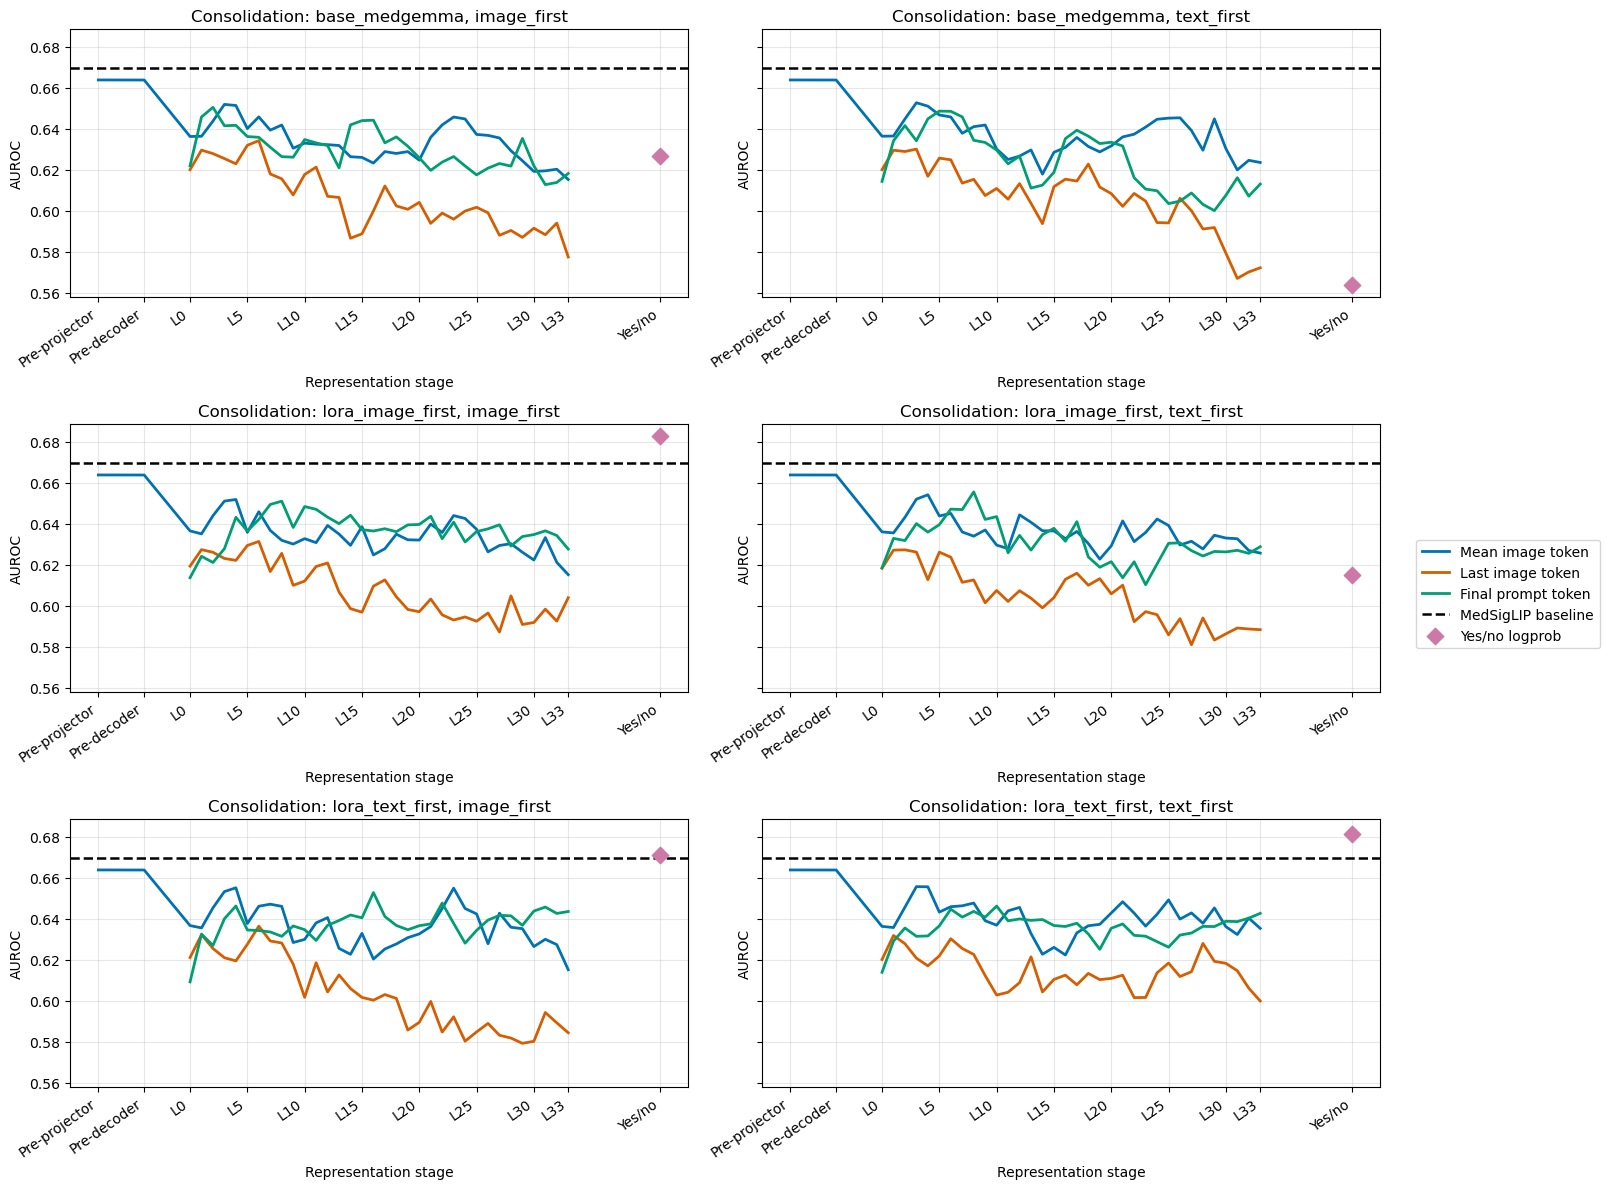

saved artifacts/plots/consolidation_auroc_over_layers.png


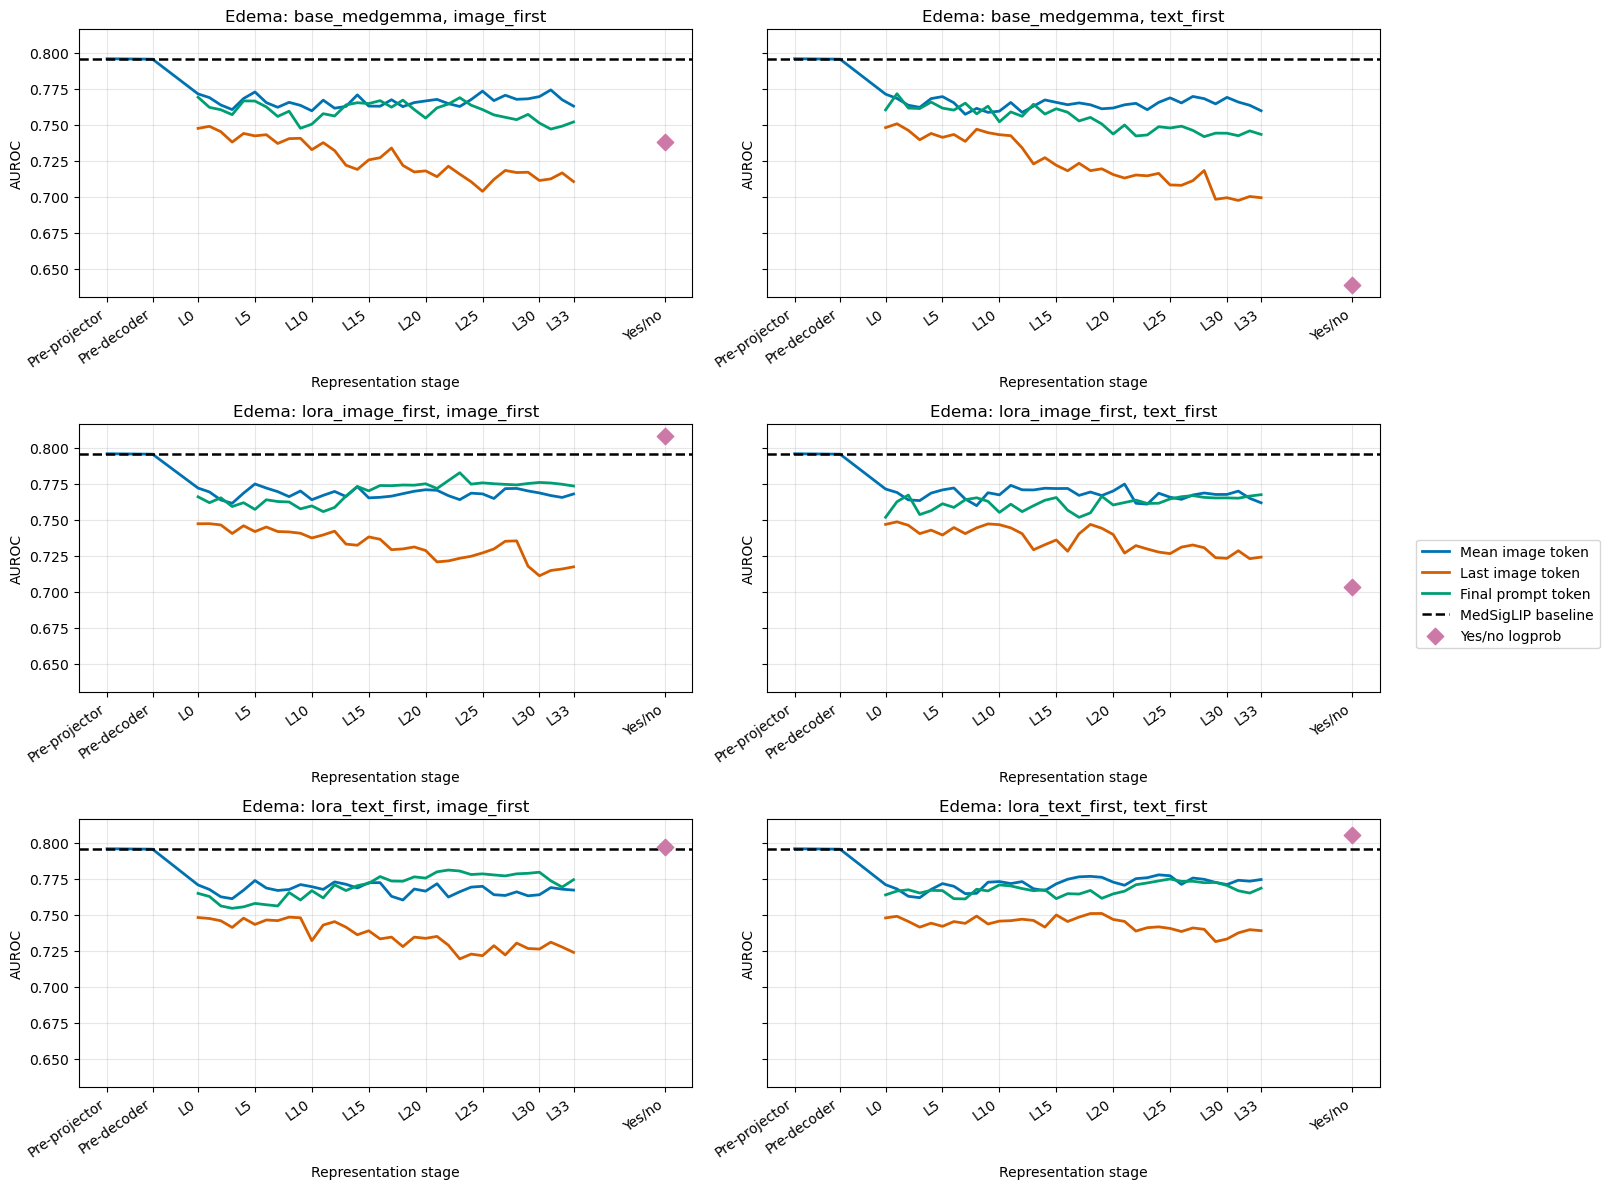

saved artifacts/plots/edema_auroc_over_layers.png


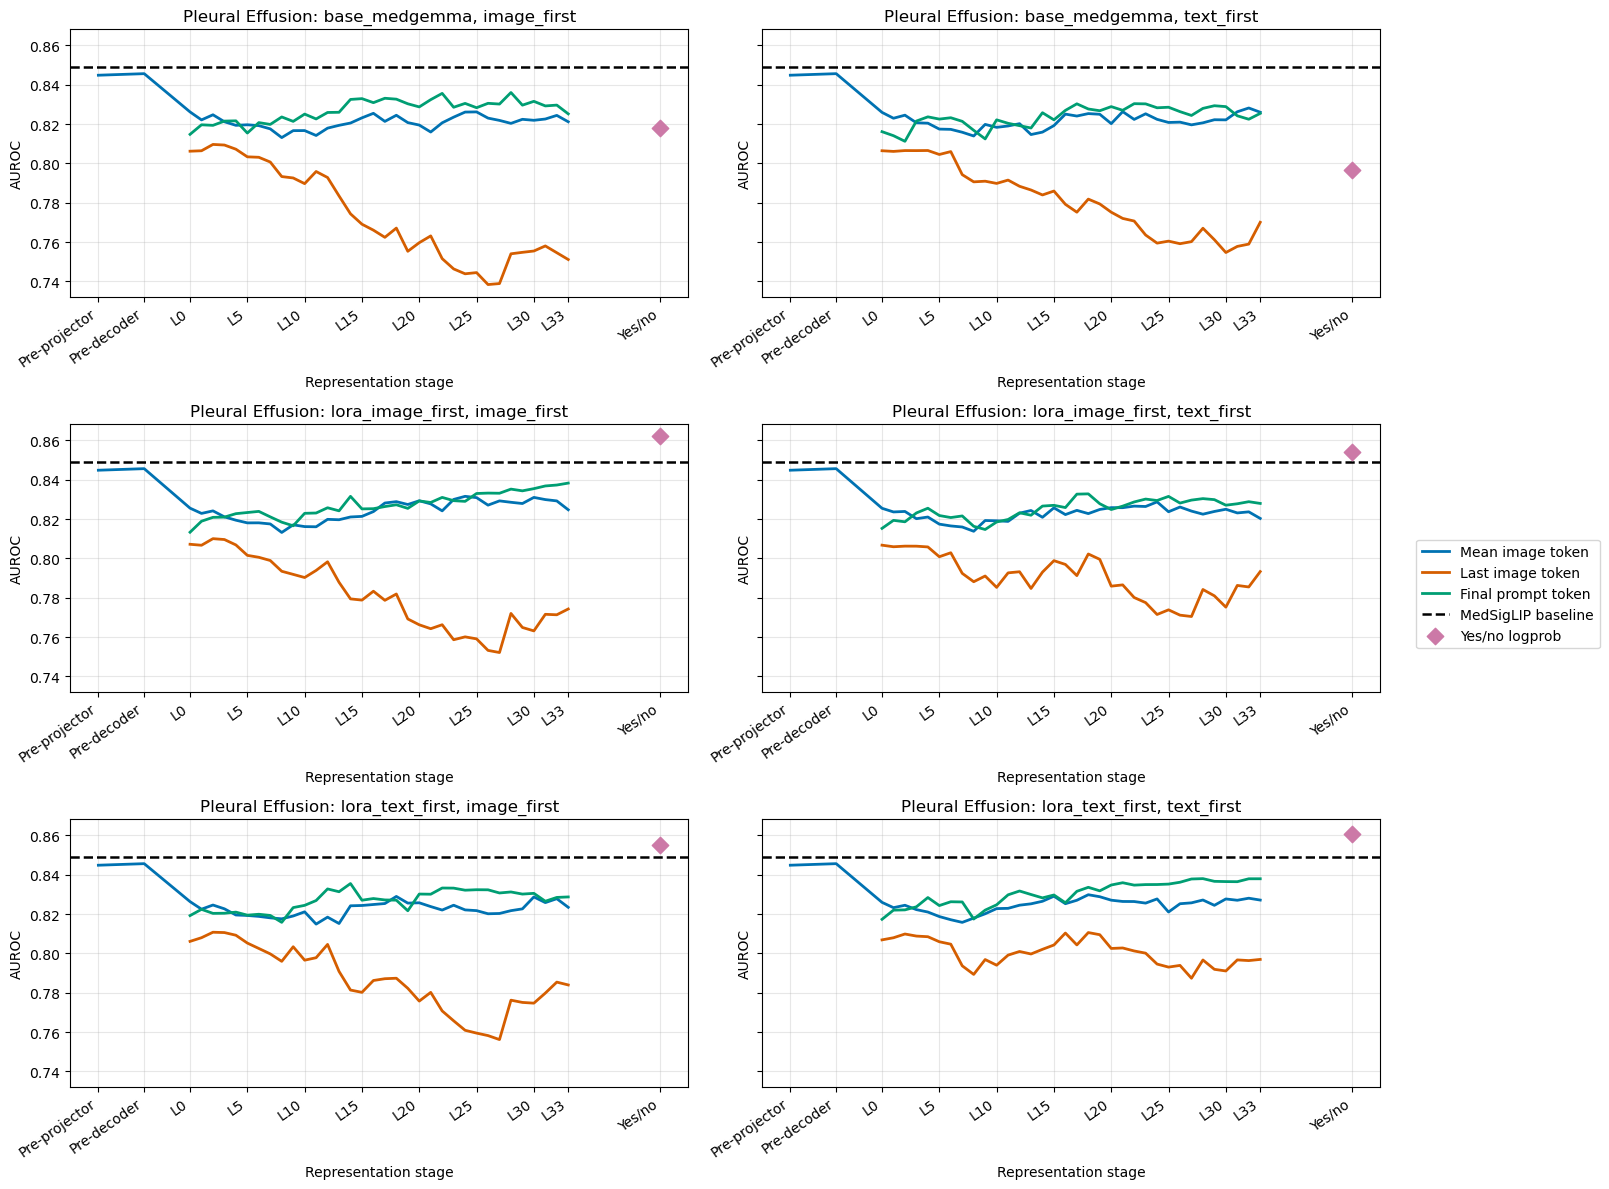

saved artifacts/plots/pleural_effusion_auroc_over_layers.png


In [12]:
metrics_df = pd.read_csv("artifacts/results/experiment_metrics.csv")
plot_dir = Path("artifacts/plots")
plot_dir.mkdir(parents=True, exist_ok=True)
plot_labels = ["Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Pleural Effusion"]
if "model_name" not in metrics_df.columns:
    metrics_df["model_name"] = np.where(metrics_df["feature"].eq("medsiglip_standalone"), "medsiglip_standalone", "base_medgemma")
metrics_df["layer"] = pd.to_numeric(metrics_df["layer"], errors="coerce")

feature_colors = {
    "mean_image_token": "#0072B2",
    "last_image_token": "#D55E00",
    "final_prompt_token": "#009E73",
    "medsiglip_baseline": "#000000",
    "yes_no_logprob": "#CC79A7",
}
plot_model_names = [name for name in ["base_medgemma", "lora_image_first", "lora_text_first"] if name in set(metrics_df["model_name"])]
max_layer = int(metrics_df["layer"].dropna().max())
has_preprojector = metrics_df["feature"].eq("medgemma_pre_projector_mean_image_token").any()
preprojector_x = -8
predecoder_x = -4
yes_no_x = max_layer + 8
pre_ticks = [preprojector_x, predecoder_x] if has_preprojector else [predecoder_x]
pre_tick_labels = ["Pre-projector", "Pre-decoder"] if has_preprojector else ["Pre-decoder"]
layer_ticks = list(range(0, max_layer + 1, 5))
if max_layer not in layer_ticks:
    layer_ticks.append(max_layer)

for label in [None] + plot_labels:
    fig, axes = plt.subplots(len(plot_model_names), 2, figsize=(14, 4 * len(plot_model_names)), sharey=True, squeeze=False)
    for row_i, model_name in enumerate(plot_model_names):
        for col_i, prompt_order in enumerate(["image_first", "text_first"]):
            ax = axes[row_i, col_i]
            sub_df = metrics_df[(metrics_df["model_name"] == model_name) & (metrics_df["prompt_order"] == prompt_order)]
            baseline_df = metrics_df[metrics_df["feature"] == "medsiglip_standalone"]
            if label is not None:
                sub_df = sub_df[sub_df["label"] == label]
                baseline_df = baseline_df[baseline_df["label"] == label]

            mean_df = sub_df[sub_df["feature"] == "medgemma_layer_mean_image_token"]
            if not mean_df.empty:
                mean_df = mean_df.groupby("layer", as_index=False).agg(auroc=("auroc", "mean")) if label is None else mean_df.sort_values("layer")
                preprojector_df = sub_df[sub_df["feature"] == "medgemma_pre_projector_mean_image_token"]
                predecoder_df = sub_df[sub_df["feature"] == "medgemma_pre_decoder_mean_image_token"]
                x = mean_df["layer"].tolist()
                y = mean_df["auroc"].tolist()
                if not predecoder_df.empty:
                    x = [predecoder_x] + x
                    y = [predecoder_df["auroc"].mean() if label is None else predecoder_df["auroc"].iloc[0]] + y
                if not preprojector_df.empty:
                    x = [preprojector_x] + x
                    y = [preprojector_df["auroc"].mean() if label is None else preprojector_df["auroc"].iloc[0]] + y
                ax.plot(x, y, color=feature_colors["mean_image_token"], linewidth=2.0, label="Mean image token")

            last_df = sub_df[sub_df["feature"] == "medgemma_layer_last_image_token"]
            if not last_df.empty:
                last_df = last_df.groupby("layer", as_index=False).agg(auroc=("auroc", "mean")) if label is None else last_df.sort_values("layer")
                ax.plot(last_df["layer"], last_df["auroc"], color=feature_colors["last_image_token"], linewidth=2.0, label="Last image token")

            final_df = sub_df[sub_df["feature"] == "medgemma_layer_final_prompt_token"]
            if not final_df.empty:
                final_df = final_df.groupby("layer", as_index=False).agg(auroc=("auroc", "mean")) if label is None else final_df.sort_values("layer")
                ax.plot(final_df["layer"], final_df["auroc"], color=feature_colors["final_prompt_token"], linewidth=2.0, label="Final prompt token")

            if not baseline_df.empty:
                ax.axhline(baseline_df["auroc"].mean() if label is None else baseline_df["auroc"].iloc[0], color=feature_colors["medsiglip_baseline"], linestyle="--", linewidth=1.8, label="MedSigLIP baseline")

            yes_no_df = sub_df[sub_df["feature"] == "medgemma_yes_no_logprob"]
            if not yes_no_df.empty:
                ax.scatter([yes_no_x], [yes_no_df["auroc"].mean() if label is None else yes_no_df["auroc"].iloc[0]], color=feature_colors["yes_no_logprob"], marker="D", s=70, zorder=5, label="Yes/no logprob")

            ax.set_title(f"{model_name}: {prompt_order}" if label is None else f"{label}: {model_name}, {prompt_order}")
            ax.set_xlabel("Representation stage")
            ax.set_ylabel("AUROC")
            ax.set_xticks(pre_ticks + layer_ticks + [yes_no_x])
            ax.set_xticklabels(pre_tick_labels + [f"L{i}" for i in layer_ticks] + ["Yes/no"], rotation=35, ha="right")
            ax.grid(True, alpha=0.3)

    handles, names = [], []
    for ax in axes.ravel():
        for handle, name in zip(*ax.get_legend_handles_labels()):
            if name not in names:
                handles.append(handle)
                names.append(name)
    fig.legend(handles, names, loc="center left", bbox_to_anchor=(1.01, 0.5))
    fig.tight_layout()
    plot_name = "mean_auroc_over_layers.png" if label is None else re.sub(r"[^a-z0-9]+", "_", label.lower()).strip("_") + "_auroc_over_layers.png"
    plot_path = plot_dir / plot_name
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print("saved", plot_path)


In [13]:
# Export report tables as CSV and LaTeX.

TABLES_DIR = Path("artifacts/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

metrics_df = pd.read_csv("artifacts/results/experiment_metrics.csv")
if "model_name" not in metrics_df.columns:
    metrics_df["model_name"] = np.where(metrics_df["feature"].eq("medsiglip_standalone"), "medsiglip_standalone", "base_medgemma")
metrics_df["layer"] = pd.to_numeric(metrics_df["layer"], errors="coerce")

feature_names = {
    "medsiglip_standalone": "MedSigLIP baseline",
    "medgemma_pre_projector_mean_image_token": "Pre-projector image token",
    "medgemma_pre_decoder_mean_image_token": "Pre-decoder image token",
    "medgemma_layer_mean_image_token": "Mean image token",
    "medgemma_layer_last_image_token": "Last image token",
    "medgemma_layer_final_prompt_token": "Final prompt token",
    "medgemma_yes_no_logprob": "Yes/no logprob",
}

model_names = {
    "base_medgemma": "Base MedGemma",
    "lora_image_first": "LoRA image-first",
    "lora_text_first": "LoRA text-first",
    "medsiglip_standalone": "MedSigLIP",
}


def make_table(label=None):
    source_df = metrics_df if label is None else metrics_df[metrics_df["label"].eq(label)]
    rows = []

    medsiglip_df = source_df[source_df["feature"].eq("medsiglip_standalone")]
    if not medsiglip_df.empty:
        rows.append({
            "Model": "MedSigLIP",
            "Representation": "MedSigLIP baseline",
            "Prompt order": "--",
            "Best layer": "--",
            "AUROC": medsiglip_df["auroc"].mean(),
        })

    for model_name in ["base_medgemma", "lora_image_first", "lora_text_first"]:
        model_df = source_df[source_df["model_name"].eq(model_name)]
        if model_df.empty:
            continue

        for feature in ["medgemma_pre_projector_mean_image_token", "medgemma_pre_decoder_mean_image_token"]:
            sub = model_df[model_df["feature"].eq(feature)]
            if not sub.empty:
                rows.append({
                    "Model": model_names.get(model_name, model_name),
                    "Representation": feature_names[feature],
                    "Prompt order": "--",
                    "Best layer": "--",
                    "AUROC": sub["auroc"].mean(),
                })

        for feature in ["medgemma_layer_mean_image_token", "medgemma_layer_last_image_token", "medgemma_layer_final_prompt_token"]:
            for prompt_order in ["image_first", "text_first"]:
                sub = model_df[model_df["feature"].eq(feature) & model_df["prompt_order"].eq(prompt_order)]
                if not sub.empty:
                    best = (
                        sub.groupby("layer", as_index=False)
                        .agg(AUROC=("auroc", "mean"))
                        .sort_values("AUROC", ascending=False)
                        .iloc[0]
                    )
                    rows.append({
                        "Model": model_names.get(model_name, model_name),
                        "Representation": feature_names[feature],
                        "Prompt order": prompt_order.replace("_", "-"),
                        "Best layer": f"L{int(best['layer'])}",
                        "AUROC": best["AUROC"],
                    })

        for prompt_order in ["image_first", "text_first"]:
            sub = model_df[model_df["feature"].eq("medgemma_yes_no_logprob") & model_df["prompt_order"].eq(prompt_order)]
            if not sub.empty:
                rows.append({
                    "Model": model_names.get(model_name, model_name),
                    "Representation": "Yes/no logprob",
                    "Prompt order": prompt_order.replace("_", "-"),
                    "Best layer": "--",
                    "AUROC": sub["auroc"].mean(),
                })

    table = pd.DataFrame(rows)
    table["AUROC"] = table["AUROC"].round(3)
    return table


def bold_max_tex(table):
    tex_table = table.copy()
    max_value = tex_table["AUROC"].max()
    tex_table["AUROC"] = tex_table["AUROC"].map(lambda x: f"\\textbf{{{x:.3f}}}" if x == max_value else f"{x:.3f}")
    return tex_table.to_latex(index=False, escape=False)


all_tables = {"mean": make_table(None)}
for label in ["Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Pleural Effusion"]:
    all_tables[re.sub(r"[^a-z0-9]+", "_", label.lower()).strip("_")] = make_table(label)

for name, table in all_tables.items():
    csv_path = TABLES_DIR / f"representation_{name}.csv"
    tex_path = TABLES_DIR / f"representation_{name}.tex"
    table.to_csv(csv_path, index=False)
    tex_path.write_text(bold_max_tex(table), encoding="utf-8")
    print("saved", csv_path)
    print("saved", tex_path)
    display(table)

saved artifacts/tables/representation_mean.csv
saved artifacts/tables/representation_mean.tex


,Model,Representation,Prompt order,Best layer,AUROC
0,MedSigLIP,MedSigLIP baseline,--,--,0.759
1,Base MedGemma,Pre-projector image token,--,--,0.755
2,Base MedGemma,Pre-decoder image token,--,--,0.755
3,Base MedGemma,Mean image token,image-first,L0,0.731
4,Base MedGemma,Mean image token,text-first,L0,0.731
5,Base MedGemma,Last image token,image-first,L0,0.713
6,Base MedGemma,Last image token,text-first,L0,0.713
7,Base MedGemma,Final prompt token,image-first,L14,0.730
8,Base MedGemma,Final prompt token,text-first,L6,0.729
9,Base MedGemma,Yes/no logprob,image-first,--,0.697


saved artifacts/tables/representation_atelectasis.csv
saved artifacts/tables/representation_atelectasis.tex


,Model,Representation,Prompt order,Best layer,AUROC
0,MedSigLIP,MedSigLIP baseline,--,--,0.669
1,Base MedGemma,Pre-projector image token,--,--,0.663
2,Base MedGemma,Pre-decoder image token,--,--,0.663
3,Base MedGemma,Mean image token,image-first,L0,0.645
4,Base MedGemma,Mean image token,text-first,L0,0.645
5,Base MedGemma,Last image token,image-first,L0,0.623
6,Base MedGemma,Last image token,text-first,L0,0.623
7,Base MedGemma,Final prompt token,image-first,L20,0.643
8,Base MedGemma,Final prompt token,text-first,L28,0.639
9,Base MedGemma,Yes/no logprob,image-first,--,0.497


saved artifacts/tables/representation_cardiomegaly.csv
saved artifacts/tables/representation_cardiomegaly.tex


...

,Model,Representation,Prompt order,Best layer,AUROC
0,MedSigLIP,MedSigLIP baseline,--,--,0.670
1,Base MedGemma,Pre-projector image token,--,--,0.664
2,Base MedGemma,Pre-decoder image token,--,--,0.664
3,Base MedGemma,Mean image token,image-first,L3,0.652
4,Base MedGemma,Mean image token,text-first,L3,0.653
5,Base MedGemma,Last image token,image-first,L6,0.634
6,Base MedGemma,Last image token,text-first,L3,0.630
7,Base MedGemma,Final prompt token,image-first,L2,0.650
8,Base MedGemma,Final prompt token,text-first,L5,0.649
9,Base MedGemma,Yes/no logprob,image-first,--,0.627


saved artifacts/tables/representation_edema.csv
saved artifacts/tables/representation_edema.tex


,Model,Representation,Prompt order,Best layer,AUROC
0,MedSigLIP,MedSigLIP baseline,--,--,0.796
1,Base MedGemma,Pre-projector image token,--,--,0.796
2,Base MedGemma,Pre-decoder image token,--,--,0.795
3,Base MedGemma,Mean image token,image-first,L31,0.774
4,Base MedGemma,Mean image token,text-first,L0,0.771
5,Base MedGemma,Last image token,image-first,L1,0.749
6,Base MedGemma,Last image token,text-first,L1,0.751
7,Base MedGemma,Final prompt token,image-first,L0,0.769
8,Base MedGemma,Final prompt token,text-first,L1,0.771
9,Base MedGemma,Yes/no logprob,image-first,--,0.738


saved artifacts/tables/representation_pleural_effusion.csv
saved artifacts/tables/representation_pleural_effusion.tex


,Model,Representation,Prompt order,Best layer,AUROC
0,MedSigLIP,MedSigLIP baseline,--,--,0.849
1,Base MedGemma,Pre-projector image token,--,--,0.845
2,Base MedGemma,Pre-decoder image token,--,--,0.846
3,Base MedGemma,Mean image token,image-first,L25,0.826
4,Base MedGemma,Mean image token,text-first,L32,0.828
5,Base MedGemma,Last image token,image-first,L2,0.810
6,Base MedGemma,Last image token,text-first,L4,0.807
7,Base MedGemma,Final prompt token,image-first,L28,0.836
8,Base MedGemma,Final prompt token,text-first,L22,0.830
9,Base MedGemma,Yes/no logprob,image-first,--,0.818
